# Applying Fitts' law to Wikispeedia

In [56]:
from DataLoader import DataLoader
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, SimilarityFunction
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import stats

tqdm.pandas()

In [42]:
dataloader = DataLoader("data")
dataloader.load_paths("paths_finished.tsv")
dataloader.load_edges("links.tsv")
dataloader.paths

,hashedIpAddress,timestamp,durationInSec,path,rating,Goal
0,3824310e536af032,1344753412,88,"[14th_century, Europe, Africa, Atlantic_slave_...",3.0,African_slave_trade
1,415612e93584d30e,1349298640,138,"[14th_century, Niger, Nigeria, British_Empire,...",NaN,African_slave_trade
2,64dd5cd342e3780c,1265613925,37,"[14th_century, Renaissance, Ancient_Greece, Gr...",NaN,Greece
3,015245d773376aab,1366730828,175,"[14th_century, Italy, Roman_Catholic_Church, H...",3.0,John_F._Kennedy
4,5295bca242be81fe,1372890414,110,"[14th_century, Europe, North_America, United_S...",NaN,John_F._Kennedy
...,...,...,...,...,...,...
51312,15a13a1d66ef5456,1349231015,66,"[Yagan, Ancient_Egypt, Civilization]",NaN,Civilization
51313,2ef7ac844cefda58,1300254138,165,"[Yagan, Folklore, Brothers_Grimm, Folklore, 19...",3.0,Fiction
51314,12863abb7887f890,1385095372,228,"[Yagan, Australia, England, France, United_Sta...",NaN,U.S._Open_%28tennis%29
51315,19f8284371753362,1298792567,56,"[Yarralumla%2C_Australian_Capital_Territory, A...",1.0,Abraham_Lincoln


In [64]:
dataloader.paths.sort_values(by="durationInSec")[:50000]

,hashedIpAddress,timestamp,durationInSec,path,rating,Goal
9588,5590014e126275b4,1225696755,0,[Moon],NaN,Moon
34301,43f864c75b2571b5,1350587407,0,[American_Samoa],NaN,American_Samoa
50465,43f864c75b2571b5,1350587414,0,[William_and_Mary],NaN,William_and_Mary
38926,43f864c75b2571b5,1350587383,0,[Florence_Nightingale],NaN,Florence_Nightingale
5856,43f864c75b2571b5,1350587401,0,[Lesotho],NaN,Lesotho
...,...,...,...,...,...,...
20287,038fa48f0d6caadf,1301670739,555,"[Pyramid, France, Portuguese_language, Brazil,...",4.0,Bean
1532,581af58d2fafd5d5,1353011517,555,"[Batman, Scotland, Ireland, United_Kingdom, Wo...",NaN,The_Holocaust
34130,745767f253f72034,1230736027,555,"[Al_Jazeera, Afghanistan, India, Indian_indepe...",NaN,Indian_independence_movement
47827,18f04531320cff22,1255905866,555,"[Tank, World_War_II, United_Kingdom, Market, M...",5.0,Asparagus


## Embed article titles as distance metric

In [43]:
model = SentenceTransformer("all-MiniLM-L6-v2")
model.similarity_fn_name = SimilarityFunction.EUCLIDEAN

In [44]:
articles = pd.read_csv('data/articles.tsv', sep='\t')

In [45]:
embeddings_array = model.encode(articles['article'], show_progress_bar=True)
embeddings = {}
for i, article in enumerate(articles['article']):
    embeddings[article] = embeddings_array[i]

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

## Load optimal paths

In [192]:
llm_optimal = { k : g.distance.to_dict() for k,g in pd.read_csv("pairs_llm_distances.csv").set_index("source").groupby("target") }

In [193]:
click_optimal = { k : g.distance.to_dict() for k,g in pd.read_csv("pairs_click_distances.csv").set_index("source").groupby("target") }

# Analyze paths

In [ ]:
def analyze_path(p):
    try:
        path = p['path']
        if len(path) < 2:
            # ignore non-games
            return None
        target_pagerank = dataloader.pagerank[path[-1]] # use pagerank as size
        # distance = -float(model.similarity(embeddings[path[0]], embeddings[path[-1]]))
        graph_llm_distance = llm_optimal[path[0]][path[-1]]
        distance = llm_optimal[path[-1]][path[0]]
        difficulty = math.log2(distance / target_pagerank)
        time = p['durationInSec']
        if time > 600:
            # ignore outliers
            return None
        return pd.Series([path[0], path[-1], 1, time, difficulty, distance, graph_llm_distance, target_pagerank])
    except KeyError:
        return None


df = dataloader.paths.progress_apply(analyze_path, axis=1).dropna()
df.columns = ["Source", "Target", "Count", "Time", "ID", "SemDistance", "PageRank"]
df

100%|██████████| 51317/51317 [00:05<00:00, 9838.21it/s] 


,Source,Target,Count,Time,ID,Distance,PageRank
0,14th_century,African_slave_trade,1.0,88.0,14.796754,1.175529,0.000041
1,14th_century,African_slave_trade,1.0,138.0,14.796754,1.175529,0.000041
2,14th_century,Greece,1.0,37.0,9.413280,1.134654,0.001664
3,14th_century,John_F._Kennedy,1.0,175.0,11.872130,1.212270,0.000323
4,14th_century,John_F._Kennedy,1.0,110.0,11.872130,1.212270,0.000323
...,...,...,...,...,...,...,...
51312,Yagan,Civilization,1.0,66.0,11.090710,1.251362,0.000574
51313,Yagan,Fiction,1.0,165.0,12.775375,1.241741,0.000177
51314,Yagan,U.S._Open_%28tennis%29,1.0,228.0,13.074862,1.297113,0.000150
51315,Yarralumla%2C_Australian_Capital_Territory,Abraham_Lincoln,1.0,56.0,11.656392,1.326535,0.000411


## Take means of path times and filter by number of occurences

In [206]:
df_mean = df.groupby(["Source", "Target"]).agg({
    "Count": "sum",
    "Time": "mean",
    "ID": "mean",
    "Distance": "mean",
    "PageRank": "mean"
}) # .filter(lambda x: x['Count'] >= 3, axis=0)

df_mean_filtered = df_mean[df_mean["Count"] >= 3]

In [207]:
df_mean_filtered

Count        Time         ID  \
Source        Target                                                     
10th_century  11th_century                  3.0    4.333333   9.975452   
11th_century  Taiwan                        3.0   68.000000  10.716659   
12th_century  Guitar                        4.0  119.000000  12.113010   
              Zimbabwe                      5.0  188.600000  11.340786   
14th_century  Elizabeth_I_of_England        5.0  147.000000  11.505239   
...                                         ...         ...        ...   
Zeus          North_Korea                   5.0  120.800000  10.917966   
Zinc          American_Revolutionary_War    3.0  136.000000  11.867002   
Zinc_chloride Age_of_Enlightenment          3.0  180.666667  11.142504   
Zulu          Aluminium                     3.0   97.666667  10.644268   
              Arctic_Circle                 3.0  100.666667  12.432939   

                                          Distance  PageRank  
Source        Target                                          
10th_century  11th_century                0.548883  0.000545  
11th_century  Taiwan                      1.233202  0.000733  
12th_century  Guitar                      1.276155  0.000288  
              Zimbabwe                    1.182378  0.000456  
14th_century  Elizabeth_I_of_England      1.133694  0.000390  
...                                            ...       ...  
Zeus          North_Korea                 1.175618  0.000608  
Zinc          American_Revolutionary_War  1.308934  0.000350  
Zinc_chloride Age_of_Enlightenment        1.356794  0.000600  
Zulu          Aluminium                   1.193095  0.000745  
              Arctic_Circle               1.264727  0.000229  

[3728 rows x 5 columns]

In [208]:
X = df_mean_filtered["ID"]
y = df_mean_filtered["Time"]

In [209]:
slope, intercept, rval, pval, stderr = stats.linregress(X, y)
print(f"rval = {rval}, y = {slope} x + {intercept}")

rval = 0.38573753813477796, y = 17.491977406748145 x + -73.02243126677561


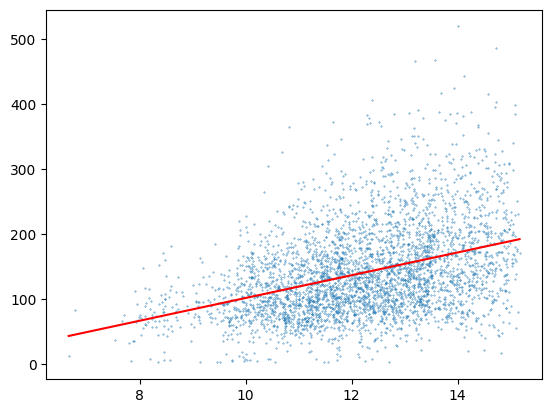

In [210]:
plt.scatter(X, y, s=0.1)

xs = np.linspace(min(X), max(X))
ys = slope*xs + intercept
plt.plot(xs, ys, color="red")
plt.show()